This notebook is a simple example of bounding an experimental design and simulating a few replicates.

# Imports

In [0]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np
import dask.dataframe as dd
 

#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

2025-09-03 16:34:49.671257: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-03 16:34:49.705559: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/Code-Server/4.17.0/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

# Create cluster

In [1]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='24GB')
client=Client(cluster)

# Seting experimiental design parameters

In [2]:
#first, we define the new parameters we want to assign to this object.

new_cell_number=pd.Series({"reference":1000,"blood":2000,"neuron":1000})

#we make up 3x replicates
new_zi=pd.Series({"replicate_A":0.02,"replicate_B":0.021})

new_min=1
new_max=200

new_MOI=60

In [3]:
#next, let's create 
artificial_bounds=scm.SHENDURE_BOUNDS.copy(
    min_mpra_umi=new_min,
    max_mpra_umi=new_max,
    zi=new_zi,
    cells_per_cell_type=new_cell_number)
    
artificial_bounds.set_effective_moi(new_MOI)

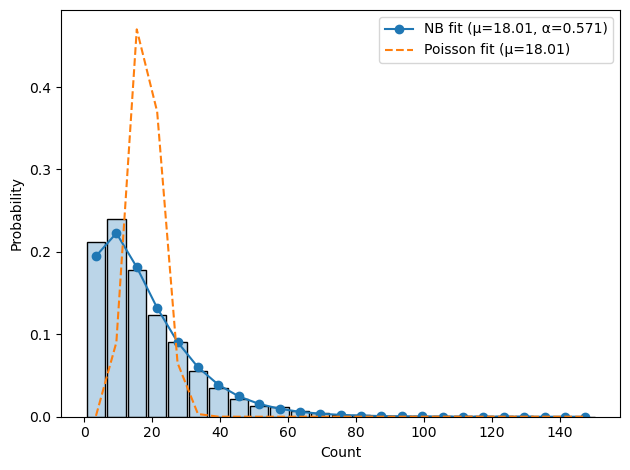

In [4]:
scm.SHENDURE_BOUNDS.plot_transfection()

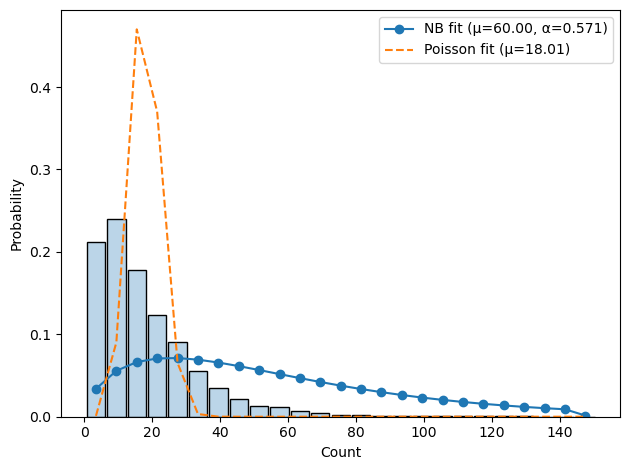

In [5]:
artificial_bounds.plot_transfection()

# Creating an artificial library

In [8]:
#making up the CREs
spread_gt,spread_hypothesis=scm.simple_spread(cell_types=new_cell_number.keys(),
                  min=new_min,
                  max=new_max)

library=scm.simulate_library(CREs=spread_gt["cre_id"],
                 library_model=artificial_bounds.library_model)

# Performing de-novo simulation

In [10]:
batch_plus=scm.de_novo_simulation(
                        simulation_replicates=3,
                        experiment_bounds=artificial_bounds,
                        ground_truth=spread_gt,
                        library=library)

In [11]:
batch_plus.gamut(client)

# Testing parameter recapitulation

In [12]:
test_data=batch_plus.simulated_scMPRA[0].result()

In [13]:
test_data.ortho_filter()

scMPRAforge: INFO: Dropped 0 of 150 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [14]:
primordial=scm.ortho()
primordial.criss_cross(client=client,
                       dat=test_data)
primordial.extract_params(client)

In [15]:
primordial.compute_model_qc()

In [ ]:
cell=[]
for i in primordial.by_cell_qc:
    working=primordial.by_cell_qc[i]["dat"]
    working["cell_type"]=i
    cell.append(working)

cell=pd.concat(cell).reset_index()
cell.merge(spread_gt,on=["cre_id","cell_type"])

In [ ]:
cell=[]
for i in primordial.by_cre_qc:
    working=primordial.by_cre_qc[i]["dat"]
    working["cre_id"]=i
    cell.append(working)

cell=pd.concat(cell).reset_index()
cell.merge(spread_gt,on=["cre_id","cell_type"])

In [ ]:
tester = scm.HypothesisTester("wald")
wald_results  = tester.run(hs_all_ct, primordial, client)

# Save

In [ ]:
data_root="/gpfs/gibbs/pi/reilly/tabula_data"

In [ ]:
#save
batch_plus.save(data_root,"simulated/simple_de_novo")

In [ ]:
cluster.close()